# outlier detection and Handling
we'll look after the normal distributed column and handle it's Outlier, by either :-
- Trimming
- Capping

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [23]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

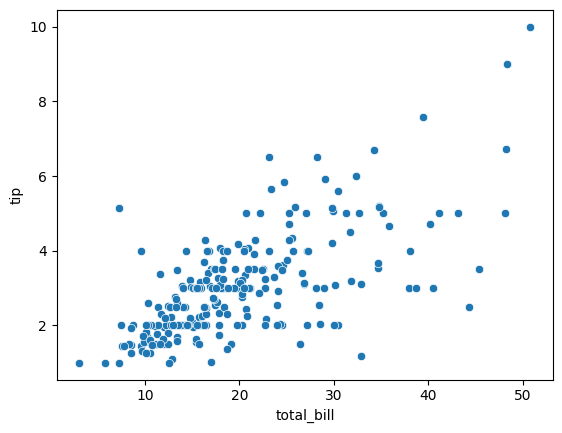

In [24]:
sns.scatterplot(x="total_bill", y="tip", data=df)

C:\Windows\Temp\ipykernel_9780\2943580123.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["total_bill"])


<Axes: xlabel='total_bill', ylabel='Density'>

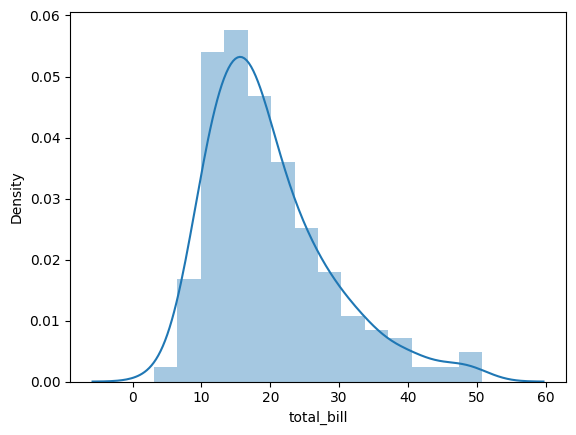

In [25]:
sns.distplot(df["total_bill"])

In [26]:
# sns.distplot(df['size'])

In [27]:
max = df['total_bill'].mean() + 3*df['total_bill'].std()
min = df['total_bill'].mean() - 3*df['total_bill'].std()
print('max:', max)
print('min:', min)

max: 46.49317848752139
min: -6.921293241619747


In [28]:
df[df['total_bill'] > max]
# since min is negative and total_bill cannot be negative, we will not consider min value for outlier detection. 
# 
# Hence, we will only consider max value for outlier detection. We can also use IQR method for out

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4


In [29]:
df.shape

(244, 7)

## trimming 
> since. 4 rows/samples are outlier, we can simply remove them

Also, we can calculate the Z-score, and detect outliers :-
$$
z = (X_i - mean) / std
$$

In [30]:
new_df = df[df['total_bill'] < max]
new_df.shape

# not removing min value outlier, cuz they aren't Outliers (logically)

(240, 7)

In [41]:
# for i in df['total_bill']:
#     if i > max:
#         i = max


df['total_bill'] = np.where(df['total_bill'] > max, max, df['total_bill'])
df[df['total_bill'] > max]

,total_bill,tip,sex,smoker,day,time,size


In [42]:
df[df['total_bill'] > max]

,total_bill,tip,sex,smoker,day,time,size


In [43]:
# done